<a href="https://colab.research.google.com/github/armaaxs/audio-brain-activity-predictor/blob/main/tribexaqademiq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!uv pip install "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"

Using Python 3.12.13 environment at: /usr
Resolved 140 packages in 875ms
Checked 140 packages in 2ms


In [ ]:
# Cell A: clean reinstall compatible stack
!pip uninstall -y numpy
!pip install -q --no-cache-dir "numpy==1.26.4"
!pip install -q --no-cache-dir "tribev2[plotting] @ git+https://github.com/facebookresearch/tribev2.git"


Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 268.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tribev2 0.1.0 requires numpy==2.2.6, but you have numpy 1.26.4 which is incompatible.
neuralset 0.0.2 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
neuraltrain 0.0.2 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.

In [ ]:
# Cell B: restart runtime NOW (required)
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

In [ ]:
# Cell 1: imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from tribev2.demo_utils import get_audio_and_text_events


/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-12 15:41:15 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_missing_as_separate_class=True to avoid this.


In [ ]:
# Cell 2: upload audio from your device
uploaded = files.upload()  # pick .wav/.mp3/.m4a/.flac


Saving trimmed.wav to trimmed.wav


In [ ]:
# Cell 3: save uploads and pick first file
CACHE_FOLDER = Path("./cache")
CACHE_FOLDER.mkdir(exist_ok=True)

audio_paths = []
for name, data in uploaded.items():
    p = CACHE_FOLDER / name
    with open(p, "wb") as f:
        f.write(data)
    audio_paths.append(p)

audio_path = audio_paths[0]  # first uploaded file
print("Using:", audio_path)
from tribev2.demo_utils import TribeModel
from tribev2.plotting import PlotBrain
from pathlib import Path

CACHE_FOLDER = Path("./cache")
CACHE_FOLDER.mkdir(exist_ok=True)

model = TribeModel.from_pretrained(
    "facebook/tribev2",
    cache_folder=CACHE_FOLDER,
)
plotter = PlotBrain(mesh="fsaverage5")

Using: cache/trimmed.wav


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/neuralset/extractors/base.py:707: UserWarning: LabelEncoder: event_types has not been set, are you sure you want to apply this extractor to all events?
  warnings.warn(
2026-05-12 15:44:21 - WARNING - neuralset.extractors.base:798 - Missing events will be encoded using the default all-zero value (for example, 0 or a zero vector/tensor), which may be indistinguishable from a valid class if that class is also mapped to zeros. Set treat_miss

In [ ]:
# Cell 4: build AUDIO-ONLY events (no text extraction)
events = pd.DataFrame([{
    "type": "Audio",
    "filepath": str(audio_path),
    "start": 0,
    "timeline": "default",
    "subject": "default",
}])

df = get_audio_and_text_events(events, audio_only=True)
display(df.head(20))


,type,start,duration,timeline,subject,session,task,run,filepath,frequency,offset,stop
0,Audio,0.0,60.000000,default,default,,,,cache/trimmed.wav,44100.0,0.0,60.000000
1,Audio,60.0,44.343696,default,default,,,,cache/trimmed.wav,44100.0,60.0,104.343696


In [ ]:
# Cell 5: predict
preds, segments = model.predict(events=df)
print("Predictions shape:", preds.shape)


[15:44:52 WARNING] Removing extractor video as there are no corresponding events
[15:44:52 WARNING] Removing extractor text as there are no corresponding events
[15:44:52 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio
Computing audio embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:20<00:00, 10.30s/it]

Computing audio embeddings: 100%|██████████| 2/2 [00:20<00:00, 10.30s/it]
[15:45:13 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-12 15:45:13 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[15:45:14 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.26s/it]
INFO - Predicted 105 / 200 se

Predictions shape: (105, 20484)


In [ ]:
# Cell 6 (RAM-safe): caps duration, frees memory, stores minimal results

!pip -q install soundfile scipy imageio

from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from scipy import signal

FIG_DIR = Path("./cache/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

MAX_SECONDS = 20          # <-- investor demo sweet spot; prevents OOM
SMOOTH_REACTION = True
SMOOTH_WINDOW = 3

def _savefig(fig, name: str):
    out = FIG_DIR / name
    fig.savefig(out, bbox_inches="tight")
    print("saved:", out)

def _load_audio_mono(path: Path):
    y, sr = sf.read(str(path), always_2d=False)
    if y.ndim > 1:
        y = y.mean(axis=1)
    return y.astype(np.float32), int(sr)

def _trim(y, sr, max_seconds):
    n = min(len(y), int(sr * max_seconds))
    return y[:n]

def _plot_waveform(y, sr, title, fname):
    # decimate for plotting speed
    step = max(1, len(y) // 200_000)
    y2 = y[::step]
    t = (np.arange(len(y2)) * step) / sr

    fig = plt.figure(figsize=(10, 2.8))
    plt.plot(t, y2, lw=0.8, color="#111827")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.2)
    _savefig(fig, fname)
    plt.close(fig)

def _plot_spectrogram(y, sr, title, fname):
    # lighter spectrogram settings
    f, t, Sxx = signal.spectrogram(
        y, fs=sr, window="hann", nperseg=512, noverlap=384, scaling="spectrum", mode="magnitude"
    )
    S = np.maximum(Sxx, 1e-10)
    S_db = 20 * np.log10(S / np.max(S))

    fig = plt.figure(figsize=(10, 3.2))
    plt.pcolormesh(t, f, S_db, shading="gouraud", cmap="magma")
    plt.ylim(0, min(8000, sr // 2))
    plt.colorbar(label="dB (relative)")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.tight_layout()
    _savefig(fig, fname)
    plt.close(fig)

def _plot_rms(y, sr, title, fname):
    frame = 2048
    hop = 512
    n = max(1, (len(y) - frame) // hop + 1)
    rms = np.empty(n, dtype=np.float32)
    for i in range(n):
        seg = y[i * hop : i * hop + frame]
        rms[i] = np.sqrt(np.mean(seg * seg) + 1e-12)
    times = (np.arange(n) * hop) / sr

    fig = plt.figure(figsize=(10, 2.8))
    plt.plot(times, rms, lw=1.2, color="#2563EB")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("RMS")
    plt.grid(True, alpha=0.2)
    _savefig(fig, fname)
    plt.close(fig)

def _safe_audio_df(model, audio_path: Path):
    try:
        from tribev2.demo_utils import get_audio_and_text_events
        events = pd.DataFrame([{
            "type": "Audio",
            "filepath": str(audio_path),
            "start": 0,
            "timeline": "default",
            "subject": "default",
        }])
        df = get_audio_and_text_events(events, audio_only=True)
        if "type" in df.columns:
            df = df[df["type"] == "Audio"].copy()
        return df
    except Exception:
        df = model.get_events_dataframe(audio_path=audio_path)
        if "type" in df.columns:
            df = df[df["type"] == "Audio"].copy()
        return df

def _reaction_from_preds(preds: np.ndarray):
    x = preds.astype(np.float32)
    x_delta = x - x.mean(axis=0, keepdims=True)
    reaction = np.sqrt((x_delta ** 2).mean(axis=1))

    if SMOOTH_REACTION and len(reaction) >= SMOOTH_WINDOW:
        k = np.ones(SMOOTH_WINDOW, dtype=np.float32) / SMOOTH_WINDOW
        reaction = np.convolve(reaction, k, mode="same")

    metrics = {
        "peak": float(np.max(reaction)) if len(reaction) else float("nan"),
        "mean": float(np.mean(reaction)) if len(reaction) else float("nan"),
        "auc": float(np.sum(reaction)) if len(reaction) else float("nan"),
    }
    return x_delta, reaction, metrics

def _plot_reaction(reaction, title, fname):
    fig = plt.figure(figsize=(10, 2.8))
    plt.plot(reaction, marker="o", lw=1.6, color="#DC2626")
    plt.title(title)
    plt.xlabel("Timestep (s)")
    plt.ylabel("RMS delta")
    plt.grid(True, alpha=0.2)
    _savefig(fig, fname)
    plt.close(fig)

def _plot_metrics_bar(metrics, title, fname):
    fig = plt.figure(figsize=(6.5, 3.2))
    keys = ["peak", "mean", "auc"]
    vals = [metrics[k] for k in keys]
    plt.bar(keys, vals, color=["#111827", "#2563EB", "#DC2626"])
    plt.title(title)
    plt.ylabel("Value")
    plt.grid(True, axis="y", alpha=0.2)
    _savefig(fig, fname)
    plt.close(fig)

# --------- Build clips (trimmed) ----------
clip_user_path = Path(audio_path)

y_user, sr_user = _load_audio_mono(clip_user_path)
y_user = _trim(y_user, sr_user, MAX_SECONDS)

# write a trimmed user file so model only sees MAX_SECONDS
clip_user_trim = Path("./cache") / "clip_user_trim.wav"
sf.write(str(clip_user_trim), y_user, sr_user)

clip_silence_path = Path("./cache") / "clip_silence.wav"
sf.write(str(clip_silence_path), np.zeros_like(y_user, dtype=np.float32), sr_user)

clip_baseline_path = Path("./cache") / "clip_baseline_noise.wav"
rng = np.random.default_rng(0)
x = rng.standard_normal(len(y_user)).astype(np.float32)
X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(len(x), d=1.0/sr_user)
X *= 1.0 / np.sqrt(np.maximum(freqs, 1e-6))
x_pink = np.fft.irfft(X).astype(np.float32)
x_pink = 0.15 * (x_pink / (np.max(np.abs(x_pink)) + 1e-6))
sf.write(str(clip_baseline_path), x_pink, sr_user)

clips = [
    ("clip_user", clip_user_trim),
    ("clip_silence", clip_silence_path),
    ("clip_baseline", clip_baseline_path),
]

# demo_results now stores ONLY lightweight stuff (+ full preds only for clip_user)
demo_results = {}

for clip_name, path in clips:
    print("\n===", clip_name, "===")

    y, sr = _load_audio_mono(path)
    y = _trim(y, sr, MAX_SECONDS)

    _plot_waveform(y, sr, f"{clip_name}: Waveform", f"{clip_name}_01_waveform.png")
    _plot_spectrogram(y, sr, f"{clip_name}: Log Spectrogram", f"{clip_name}_02_spectrogram.png")
    _plot_rms(y, sr, f"{clip_name}: Loudness (RMS) Over Time", f"{clip_name}_03_rms.png")

    df_audio = _safe_audio_df(model, path)
    preds, segments = model.predict(events=df_audio)

    x_delta, reaction, metrics = _reaction_from_preds(preds)
    _plot_reaction(reaction, f"{clip_name}: TRIBE Reaction Strength", f"{clip_name}_04_reaction.png")
    _plot_metrics_bar(metrics, f"{clip_name}: Reaction Summary", f"{clip_name}_05_metrics.png")

    demo_results[clip_name] = {
        "path": str(path),
        "duration_s": float(len(y) / sr),
        "timesteps_kept": int(preds.shape[0]),
        "reaction": reaction,
        "metrics": metrics,
    }

    # Keep heavy arrays only for clip_user so Cell 7 can use them
    if clip_name == "clip_user":
        demo_results[clip_name]["preds"] = preds
        demo_results[clip_name]["segments"] = segments
        demo_results[clip_name]["x_delta"] = x_delta

    # Free memory aggressively
    del y, df_audio
    if clip_name != "clip_user":
        del preds, segments, x_delta
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass

# Overlay comparison (lightweight)
fig = plt.figure(figsize=(10, 3.2))
colors = {"clip_user": "#DC2626", "clip_silence": "#111827", "clip_baseline": "#2563EB"}
for name in ["clip_user", "clip_silence", "clip_baseline"]:
    r = demo_results[name]["reaction"]
    plt.plot(r, marker="o", lw=1.6, label=name, color=colors.get(name))
plt.title("TRIBE Reaction Strength Comparison")
plt.xlabel("Timestep (s)")
plt.ylabel("RMS delta")
plt.grid(True, alpha=0.2)
plt.legend()
_savefig(fig, "compare_06_reaction_overlay.png")
plt.close(fig)

# Ranked summary table figure
rows = []
for name, r in demo_results.items():
    rows.append([
        name,
        f'{r["duration_s"]:.2f}',
        str(r["timesteps_kept"]),
        f'{r["metrics"]["peak"]:.4f}',
        f'{r["metrics"]["mean"]:.4f}',
        f'{r["metrics"]["auc"]:.4f}',
    ])
rows_sorted = sorted(rows, key=lambda x: float(x[3]), reverse=True)

fig = plt.figure(figsize=(10, 2.6))
plt.axis("off")
table = plt.table(
    cellText=rows_sorted,
    colLabels=["clip", "duration(s)", "timesteps", "peak", "mean", "AUC"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.4)
plt.title("TRIBE Reaction Summary (Ranked by Peak)", pad=14)
_savefig(fig, "compare_07_summary_table.png")
plt.close(fig)

gc.collect()
print("\nArtifacts in:", FIG_DIR)



=== clip_user ===
saved: cache/figures/clip_user_01_waveform.png
saved: cache/figures/clip_user_02_spectrogram.png


[15:46:14 WARNING] Removing extractor video as there are no corresponding events
[15:46:14 WARNING] Removing extractor text as there are no corresponding events
[15:46:14 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


saved: cache/figures/clip_user_03_rms.png


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[15:46:21 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-12 15:46:21 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[15:46:21 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.76s/it]
INFO - Predicted 20 / 100 segments (20.0% kept)
INFO:tribev2.demo_utils:Predicted 20 / 100 segments (20.0% kept)


...

[15:46:52 WARNING] Removing extractor video as there are no corresponding events
[15:46:52 WARNING] Removing extractor text as there are no corresponding events
[15:46:52 INFO] Preparing extractor: audio
INFO:tribev2.main:Preparing extractor: audio


saved: cache/figures/clip_baseline_03_rms.png


Loading weights:   0%|          | 0/773 [00:00<?, ?it/s]

[15:46:58 INFO] Preparing extractor: subject_id
INFO:tribev2.main:Preparing extractor: subject_id
2026-05-12 15:46:58 - WARNING - neuralset.extractors.base:824 - LabelEncoder has only found one label: {'default'}. This was probably not intended.
[15:46:58 INFO] Building dataloader for split all
INFO:tribev2.main:Building dataloader for split all
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
100%|██████████| 1/1 [00:01<00:00,  1.23s/it]
INFO - Predicted 20 / 100 segments (20.0% kept)
INFO:tribev2.demo_utils:Predicted 20 / 100 segments (20.0% kept)


saved: cache/figures/clip_baseline_04_reaction.png
saved: cache/figures/clip_baseline_05_metrics.png
saved: cache/figures/compare_06_reaction_overlay.png
saved: cache/figures/compare_07_summary_table.png

Artifacts in: cache/figures


clip_user: plotting 15 steps with vmin/vmax = -0.12556/0.12556


Plotting...: 100%|██████████| 15/15 [00:04<00:00,  3.14it/s]


saved: cache/figures/clip_user_brain_01_timesteps.png


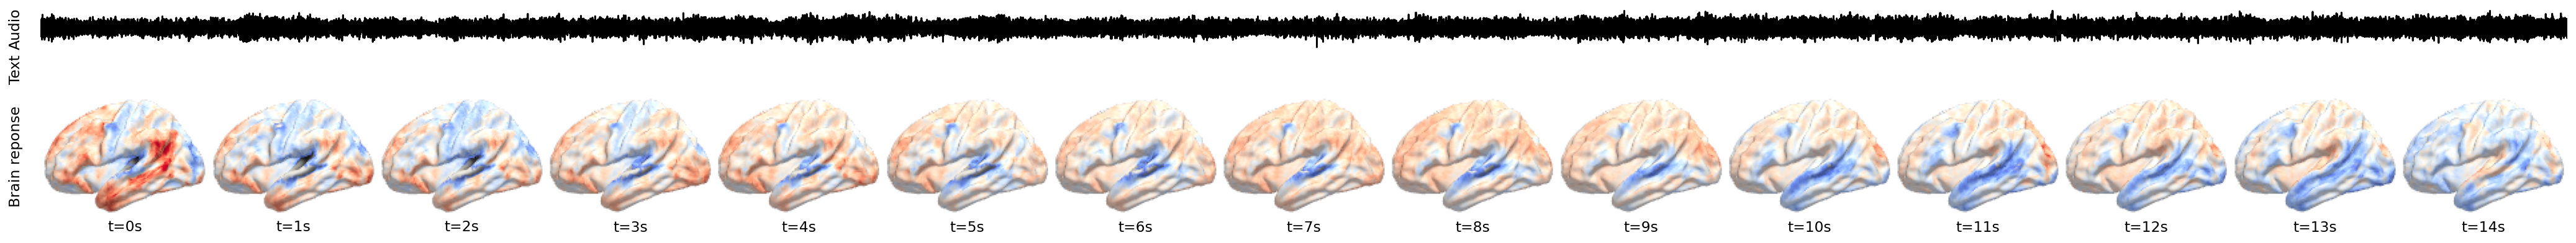

saved: cache/figures/clip_user_brain_02_top_changing_vertices.png


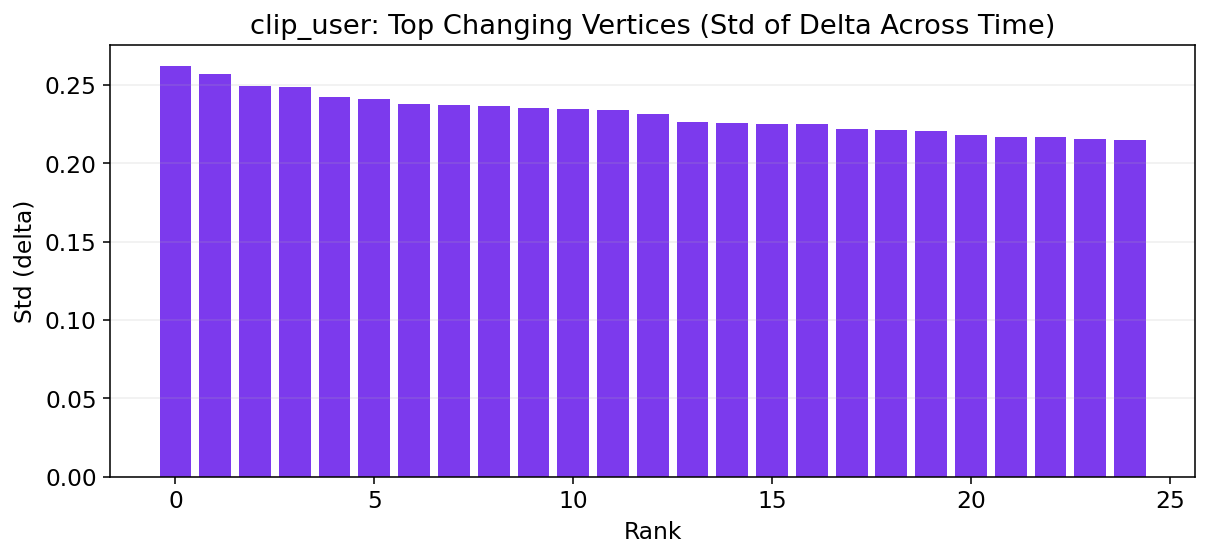

In [ ]:
# Cell 7: Brain Viz + Exports (Investor demo)

!pip -q install imageio

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

FIG_DIR = Path("./cache/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLIP_TO_VIZ = "clip_user"  # "clip_baseline" or "clip_silence"

x_delta = demo_results[CLIP_TO_VIZ]["x_delta"]
segments = demo_results[CLIP_TO_VIZ]["segments"]

n_timesteps = min(15, len(x_delta))
x_delta_15 = x_delta[:n_timesteps]

m = np.percentile(np.abs(x_delta_15), 99.5)
vmin, vmax = -m, m
print(f"{CLIP_TO_VIZ}: plotting {n_timesteps} steps with vmin/vmax = {vmin:.5f}/{vmax:.5f}")

# 1) Brain panels
fig = plotter.plot_timesteps(
    x_delta_15,
    segments=segments[:n_timesteps],
    cmap="coolwarm",
    norm_percentile=None,
    vmin=vmin,
    vmax=vmax,
    alpha_cmap=(0, 0.10),
    show_stimuli=True,
)
out_png = FIG_DIR / f"{CLIP_TO_VIZ}_brain_01_timesteps.png"
fig.savefig(out_png, bbox_inches="tight")
print("saved:", out_png)
plt.show()

# 2) Top-changing vertices proxy
vertex_std = x_delta.std(axis=0)
top_n = 25
idx = np.argsort(vertex_std)[-top_n:][::-1]
vals = vertex_std[idx]

fig = plt.figure(figsize=(10, 4))
plt.bar(np.arange(top_n), vals, color="#7C3AED")
plt.title(f"{CLIP_TO_VIZ}: Top Changing Vertices (Std of Delta Across Time)")
plt.xlabel("Rank")
plt.ylabel("Std (delta)")
plt.grid(True, axis="y", alpha=0.2)
out_png = FIG_DIR / f"{CLIP_TO_VIZ}_brain_02_top_changing_vertices.png"
fig.savefig(out_png, bbox_inches="tight")
print("saved:", out_png)
plt.show()


saved: cache/figures/clip_user_brain_02_top_changing_vertices.png


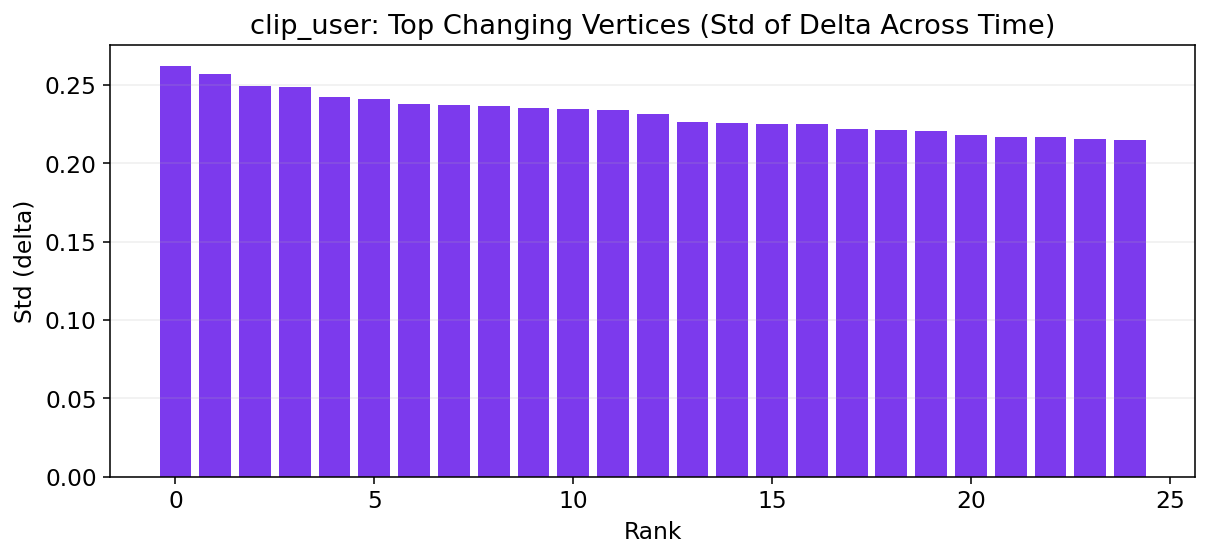

In [ ]:

# 2) Top-changing vertices proxy
vertex_std = x_delta.std(axis=0)
top_n = 25
idx = np.argsort(vertex_std)[-top_n:][::-1]
vals = vertex_std[idx]

fig = plt.figure(figsize=(10, 4))
plt.bar(np.arange(top_n), vals, color="#7C3AED")
plt.title(f"{CLIP_TO_VIZ}: Top Changing Vertices (Std of Delta Across Time)")
plt.xlabel("Rank")
plt.ylabel("Std (delta)")
plt.grid(True, axis="y", alpha=0.2)
out_png = FIG_DIR / f"{CLIP_TO_VIZ}_brain_02_top_changing_vertices.png"
fig.savefig(out_png, bbox_inches="tight")
print("saved:", out_png)
plt.show()


In [ ]:
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt

gif_path = FIG_DIR / f"{CLIP_TO_VIZ}_brain_03_timesteps.gif"
with imageio.get_writer(gif_path, mode="I", duration=0.6) as writer:
    for t in range(n_timesteps):
        fig_t = plotter.plot_timesteps(
            x_delta[t:t+1],
            segments=segments[t:t+1],
            cmap="coolwarm",
            norm_percentile=None,
            vmin=vmin,
            vmax=vmax,
            alpha_cmap=(0, 0.10),
            show_stimuli=False,
        )
        fig_t.set_size_inches(6, 4, forward=True)
        fig_t.canvas.draw()

        buf = np.asarray(fig_t.canvas.buffer_rgba())
        img = np.ascontiguousarray(buf[:, :, :3])
        writer.append_data(img)

        plt.close(fig_t)

print("saved:", gif_path)


Plotting...: 100%|██████████| 1/1 [00:02<00:00,  2.04s/it]


saved: cache/figures/clip_user_brain_03_timesteps.gif


In [ ]:
!zip -r figures.zip cache/figures
from google.colab import files
files.download("figures.zip")

  adding: cache/figures/ (stored 0%)
  adding: cache/figures/compare_06_reaction_overlay.png (deflated 7%)
  adding: cache/figures/clip_user_brain_01_timesteps.png (deflated 5%)
  adding: cache/figures/clip_user_brain_02_top_changing_vertices.png (deflated 21%)
  adding: cache/figures/clip_user_brain_03_timesteps.gif (deflated 0%)
  adding: cache/figures/clip_silence_02_spectrogram.png (deflated 18%)
  adding: cache/figures/clip_user_02_spectrogram.png (deflated 0%)
  adding: cache/figures/clip_baseline_02_spectrogram.png (deflated 0%)
  adding: cache/figures/clip_baseline_01_waveform.png (deflated 6%)
  adding: cache/figures/compare_07_summary_table.png (deflated 16%)
  adding: cache/figures/clip_baseline_04_reaction.png (deflated 11%)
  adding: cache/figures/clip_silence_01_waveform.png (deflated 21%)
  adding: cache/figures/clip_silence_05_metrics.png (deflated 22%)
  adding: cache/figures/clip_silence_03_rms.png (deflated 22%)
  adding: cache/figures/clip_silence_04_reaction.png (d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>